In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
np.random.seed(42)

n, d = 100, 50
A = np.random.randn(n, d)
x_true = np.random.randn(d)
b = A @ x_true + 0.1 * np.random.randn(n)

lam = 0.1

In [11]:
def f(x):
    return 0.5 * np.linalg.norm(A @ x - b)**2

def grad_f(x):
    return A.T @ (A @ x - b)

def g(x):
    return lam * np.linalg.norm(x, 1)

def prox_l1(x, eta):
    return np.sign(x) * np.maximum(np.abs(x) - eta * lam, 0.0)

In [12]:
#L = np.linalg.norm(A.T @ A, 2)   # spectral norm
# Above one is expensive form

L = np.linalg.norm(A, 2)**2

eta = 1.0 / L

def prox_gradient_descent(x0, max_iter=100, tol=1e-6):
    x = x0.copy()
    history = []

    for k in range(max_iter):
        x_old = x.copy()

        y = x - eta * grad_f(x)
        x = prox_l1(y, eta)

        obj = f(x) + g(x)
        history.append(obj)

        if k % 10 == 0:
            print(f"Iter {k}: Obj = {obj:.4f}")

        # stopping condition
        if np.linalg.norm(x - x_old) < tol:
            break

    return x, history

In [13]:
x0 = np.zeros(d)
x_opt, history = prox_gradient_descent(x0, max_iter=200)

Iter 0: Obj = 899.4687
Iter 10: Obj = 34.6333
Iter 20: Obj = 10.1877
Iter 30: Obj = 6.0139
Iter 40: Obj = 5.0048
Iter 50: Obj = 4.7162
Iter 60: Obj = 4.6273
Iter 70: Obj = 4.5985
Iter 80: Obj = 4.5888
Iter 90: Obj = 4.5855
Iter 100: Obj = 4.5843
Iter 110: Obj = 4.5839
Iter 120: Obj = 4.5837
Iter 130: Obj = 4.5837
Iter 140: Obj = 4.5837
Iter 150: Obj = 4.5836
Iter 160: Obj = 4.5836
Iter 170: Obj = 4.5836
Iter 180: Obj = 4.5836
Iter 190: Obj = 4.5836


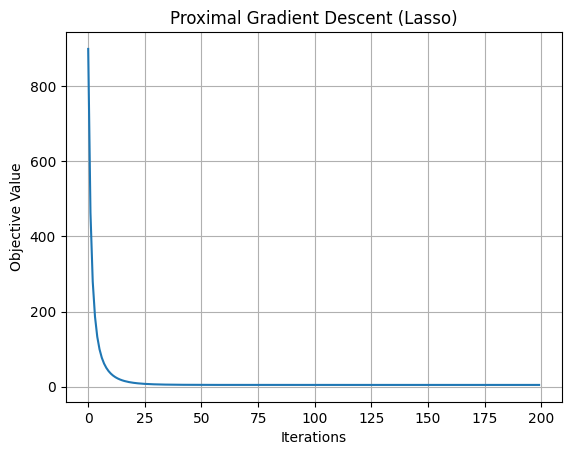

In [14]:
plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Objective Value")
plt.title("Proximal Gradient Descent (Lasso)")
plt.grid()
plt.show()

In [15]:
print("Number of non-zeros in solution:", np.sum(np.abs(x_opt) > 1e-6))
print("First 10 values:", x_opt[:10])

Number of non-zeros in solution: 50
First 10 values: [-0.43994749 -0.44533129 -1.77285161 -0.31459254  0.73305492 -1.24865001
  1.06027587  0.4826441  -0.7288311  -0.13754472]


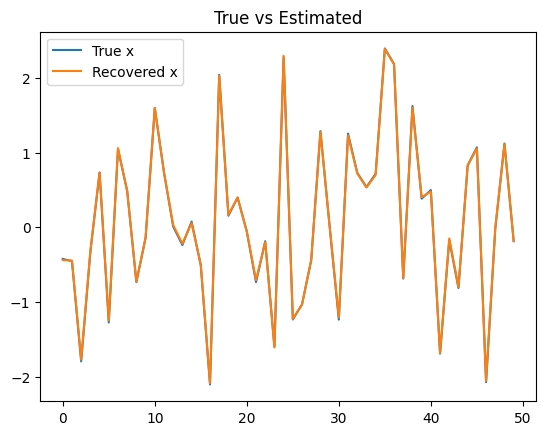

In [16]:
plt.plot(x_true, label="True x")
plt.plot(x_opt, label="Recovered x")
plt.legend()
plt.title("True vs Estimated")
plt.show()

Proximal Gradient Descent

Solves: min f(x) + g(x)

Step:
y_k = x_k - eta * grad f(x_k)
x_{k+1} = prox_{eta g}(y_k)

Here:
f = least squares
g = L1 (sparsity)

Key:
- Handles non-smooth g
- Produces sparse solutions
